In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score
)
from imblearn.over_sampling import SMOTE

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)



In [2]:
# Load the 18-feature dataset saved at end of Notebook 2
df = pd.read_csv(
    '/home/jupyter/secom-yield-optimization/data/processed/secom_selected_features.csv'
)

# Sort chronologically — critical for honest train/test split
df = df.sort_values('timestamp').reset_index(drop=True)

# Separate features, target and timestamp
feature_cols = [c for c in df.columns if c.startswith('sensor_')]
X = df[feature_cols]
y = df['label']

print(f"Dataset shape: {df.shape}")
print(f"Features: {len(feature_cols)}")
print(f"Chronological range:")
print(f"  First wafer: {df['timestamp'].iloc[0]}")
print(f"  Last wafer:  {df['timestamp'].iloc[-1]}")
print(f"\nClass distribution:")
print(y.value_counts())

Dataset shape: (1567, 20)
Features: 18
Chronological range:
  First wafer: 01/08/2008 02:02:00
  Last wafer:  31/08/2008 22:57:00

Class distribution:
label
0    1463
1     104
Name: count, dtype: int64


In [3]:
# Use first 80% of wafers (by time) for training
# Use last 20% of wafers (by time) for testing


split_idx = int(len(df) * 0.80)
split_timestamp = df['timestamp'].iloc[split_idx]

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f"Chronological train/test split")
print(f"Split point: row {split_idx} — {split_timestamp}")
print(f"\nTraining set: {X_train.shape[0]} wafers")
print(f"  Pass: {(y_train==0).sum()} | Fail: {(y_train==1).sum()} "
      f"| Failure rate: {y_train.mean()*100:.1f}%")
print(f"\nTest set: {X_test.shape[0]} wafers")
print(f"  Pass: {(y_test==0).sum()} | Fail: {(y_test==1).sum()} "
      f"| Failure rate: {y_test.mean()*100:.1f}%")

Chronological train/test split
Split point: row 1253 — 26/09/2008 13:36:00

Training set: 1253 wafers
  Pass: 1169 | Fail: 84 | Failure rate: 6.7%

Test set: 314 wafers
  Pass: 294 | Fail: 20 | Failure rate: 6.4%


In [4]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_cols)

print("Scaling complete")
print(f"\nTraining set stats after scaling:")
print(f"  Mean: {X_train_scaled.values.mean():.4f}")
print(f"  Std:  {X_train_scaled.values.std():.4f}")
print(f"\nTest set stats after scaling:")
print(f"  Mean: {X_test_scaled.values.mean():.4f}")
print(f"  Std:  {X_test_scaled.values.std():.4f}")

Scaling complete

Training set stats after scaling:
  Mean: 0.0000
  Std:  1.0000

Test set stats after scaling:
  Mean: 0.0259
  Std:  1.0590


In [5]:
from imblearn.over_sampling import SMOTE

# SMOTE generates synthetic failure examples by interpolating
# between real failures in the 18-dimensional feature space
smote = SMOTE(k_neighbors=5, random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

print("SMOTE applied to training set")
print(f"\nBefore SMOTE:")
print(f"  Pass: {(y_train==0).sum()} | Fail: {(y_train==1).sum()}")
print(f"\nAfter SMOTE:")
print(f"  Pass: {(y_train_resampled==0).sum()} | "
      f"Fail: {(y_train_resampled==1).sum()}")
print(f"\nTest set untouched:")
print(f"  Pass: {(y_test==0).sum()} | Fail: {(y_test==1).sum()}")

SMOTE applied to training set

Before SMOTE:
  Pass: 1169 | Fail: 84

After SMOTE:
  Pass: 1169 | Fail: 1169

Test set untouched:
  Pass: 294 | Fail: 20


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline


import numpy as np
from sklearn.model_selection import BaseCrossValidator

class StratifiedTimeSeriesSplit(BaseCrossValidator):
    def __init__(self, n_splits=5):
        self.n_splits = n_splits

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y, groups=None):
        y = np.array(y)
        pass_idx = np.where(y == 0)[0]
        fail_idx = np.where(y == 1)[0]
        pass_folds = np.array_split(pass_idx, self.n_splits + 1)
        fail_folds = np.array_split(fail_idx, self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            train_pass = np.concatenate(pass_folds[:i])
            train_fail = np.concatenate(fail_folds[:i])
            train_idx  = np.sort(np.concatenate([train_pass, train_fail]))
            val_pass   = pass_folds[i]
            val_fail   = fail_folds[i]
            val_idx    = np.sort(np.concatenate([val_pass, val_fail]))
            yield train_idx, val_idx

    def _iter_test_indices(self, X=None, y=None, groups=None):
        for _, test in self.split(X, y):
            yield test

stscv = StratifiedTimeSeriesSplit(n_splits=5)

# Define three models to compare
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'  # additional imbalance handling
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        random_state=42
    )
}

# Scoring metrics to evaluate across folds
scoring = {
    'f1':        'f1',
    'recall':    'recall',
    'precision': 'precision',
    'roc_auc':   'roc_auc'
}

cv_results = {}

print("Running chronological cross-validation on CV pool (first 80%)...")
print("SMOTE applied inside each fold to prevent leakage\n")
print(f"{'Model':<25} {'F1':>8} {'Recall':>8} {'Precision':>10} {'AUC-ROC':>8}")
print("-" * 65)

for name, model in models.items():
    # ImbPipeline ensures SMOTE is applied inside each CV fold
    # fit on train fold only — never leaks into validation fold
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(k_neighbors=5, random_state=42)),
        ('model',  model)
    ])

    scores = cross_validate(
        pipe, 
        X_train,      # raw unscaled training data — pipeline handles scaling
        y_train,      
        cv=stscv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results[name] = scores

    print(f"{name:<25} "
          f"{scores['test_f1'].mean():>8.4f} "
          f"{scores['test_recall'].mean():>8.4f} "
          f"{scores['test_precision'].mean():>10.4f} "
          f"{scores['test_roc_auc'].mean():>8.4f}")

Running chronological cross-validation on CV pool (first 80%)...
SMOTE applied inside each fold to prevent leakage

Model                           F1   Recall  Precision  AUC-ROC
-----------------------------------------------------------------
Logistic Regression         0.2896   0.5714     0.1971   0.7760
Random Forest               0.1334   0.1286     0.1753   0.6977
Gradient Boosting           0.2151   0.2571     0.2051   0.7006


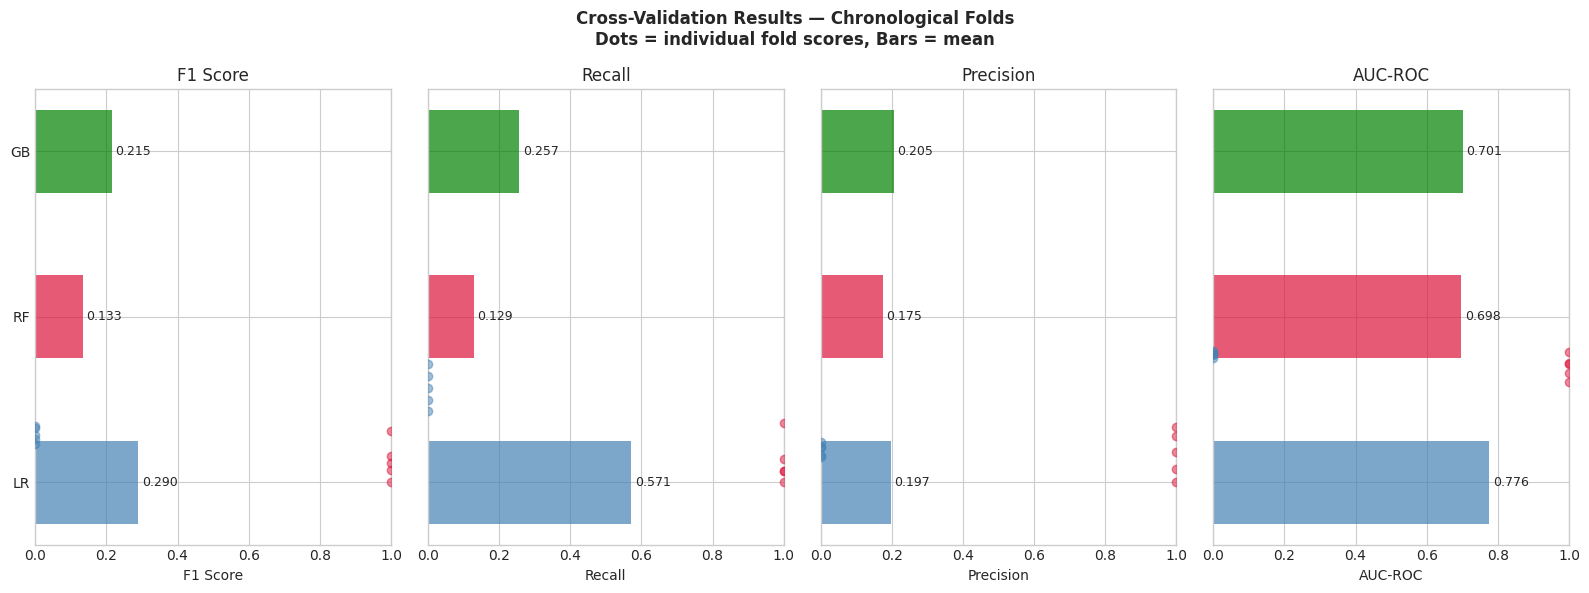

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 6))

metrics = ['f1', 'recall', 'precision', 'roc_auc']
metric_labels = ['F1 Score', 'Recall', 'Precision', 'AUC-ROC']
colors = ['steelblue', 'crimson', 'green']
model_names = list(cv_results.keys())

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx]
    
    for i, name in enumerate(model_names):
        scores = cv_results[name][f'test_{metric}']
        # Plot individual fold scores as dots
        ax.scatter([i]*len(scores), scores, 
                  color=colors[i], alpha=0.5, zorder=3)
        # Plot mean as a horizontal bar
        ax.barh(i, scores.mean(), 
               color=colors[i], alpha=0.7, height=0.5)
        # Add mean value label
        ax.text(scores.mean() + 0.01, i, 
               f'{scores.mean():.3f}', va='center', fontsize=9)
    
    ax.set_yticks(range(len(model_names)))
    ax.set_yticklabels(['LR', 'RF', 'GB'] if idx == 0 else [])
    ax.set_xlabel(label)
    ax.set_xlim(0, 1)
    ax.set_title(label)

plt.suptitle('Cross-Validation Results — Chronological Folds\n'
             'Dots = individual fold scores, Bars = mean',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/jupyter/secom-yield-optimization/data/processed/cv_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [8]:
from imblearn.pipeline import Pipeline as ImbPipeline

# Build final pipeline with Logistic Regression
final_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(k_neighbors=5, random_state=42)),
    ('model',  LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])

# Train on entire CV pool (first 80% of chronological data)
final_pipe.fit(X_train, y_train)

# Evaluate on held-out test set (last 20% — never seen during training or CV)
y_pred      = final_pipe.predict(X_test)
y_pred_prob = final_pipe.predict_proba(X_test)[:, 1]

print("Final model trained on CV pool")
print(f"Evaluated on held-out test set: {len(y_test)} wafers\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Pass (0)', 'Fail (1)']))
print(f"AUC-ROC:              {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"Average Precision:    {average_precision_score(y_test, y_pred_prob):.4f}")

Final model trained on CV pool
Evaluated on held-out test set: 314 wafers

Classification Report:
              precision    recall  f1-score   support

    Pass (0)       0.96      0.78      0.86       294
    Fail (1)       0.15      0.55      0.23        20

    accuracy                           0.77       314
   macro avg       0.55      0.67      0.55       314
weighted avg       0.91      0.77      0.82       314

AUC-ROC:              0.7354
Average Precision:    0.2270


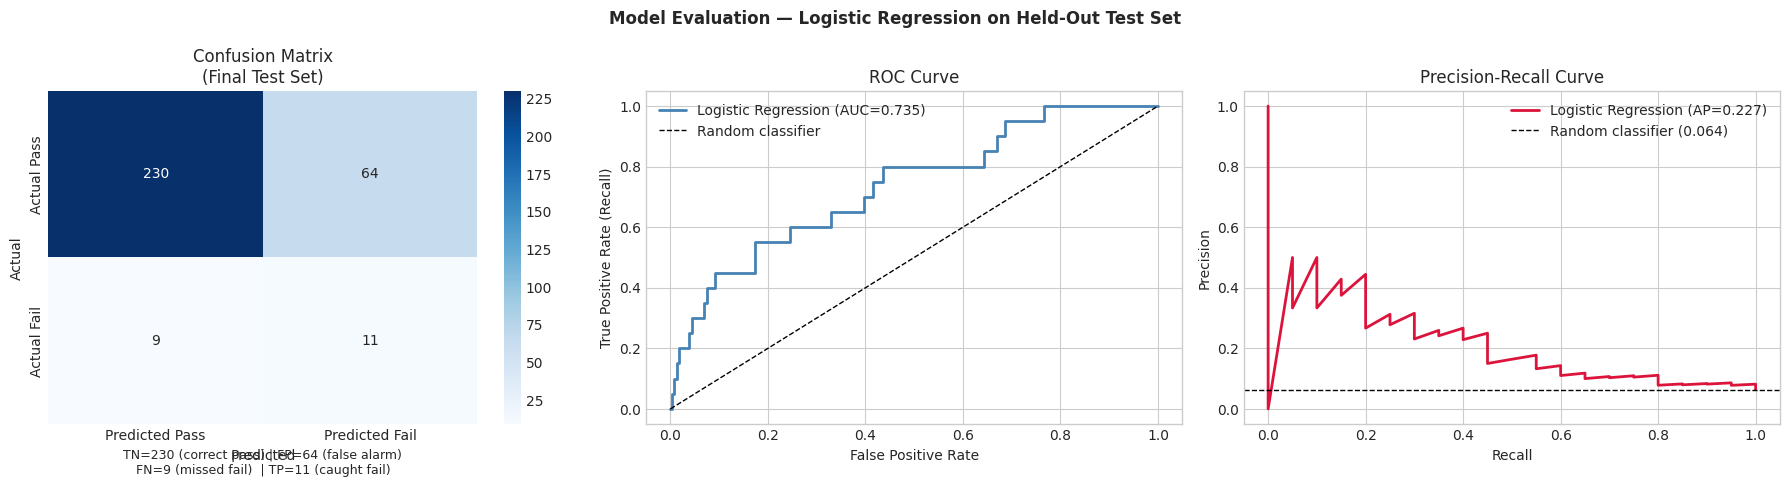

Confusion Matrix Breakdown:
  True Negatives  (correctly passed): 230
  False Positives (false alarms):     64
  False Negatives (missed failures):  9
  True Positives  (caught failures):  11

------------------------------------------------------------
  Failures caught early:  11/20 (55.0%)
  Failures missed:        9/20 (45.0%)
  False alarms per day:   ~64 good wafers flagged unnecessarily


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Pass', 'Predicted Fail'],
            yticklabels=['Actual Pass', 'Actual Fail'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix\n(Final Test Set)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Add interpretation text
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.15,
    f'TN={tn} (correct pass) | FP={fp} (false alarm)\n'
    f'FN={fn} (missed fail)  | TP={tp} (caught fail)',
    transform=axes[0].transAxes, ha='center', fontsize=9)

# Middle: ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'Logistic Regression (AUC={auc_score:.3f})')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1, label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Right: Precision-Recall Curve
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(
    y_test, y_pred_prob
)
ap_score = average_precision_score(y_test, y_pred_prob)
axes[2].plot(recall_vals, precision_vals, color='crimson', linewidth=2,
             label=f'Logistic Regression (AP={ap_score:.3f})')
axes[2].axhline(y=y_test.mean(), color='k', linestyle='--', linewidth=1,
                label=f'Random classifier ({y_test.mean():.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()

plt.suptitle('Model Evaluation — Logistic Regression on Held-Out Test Set',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/jupyter/secom-yield-optimization/data/processed/model_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print confusion matrix breakdown
print(f"Confusion Matrix Breakdown:")
print(f"  True Negatives  (correctly passed): {tn}")
print(f"  False Positives (false alarms):     {fp}")
print(f"  False Negatives (missed failures):  {fn}")
print(f"  True Positives  (caught failures):  {tp}")
print(f"\n------------------------------------------------------------")
print(f"  Failures caught early:  {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)")
print(f"  Failures missed:        {fn}/{tp+fn} ({fn/(tp+fn)*100:.1f}%)")
print(f"  False alarms per day:   ~{fp} good wafers flagged unnecessarily")

In [11]:
# Create a risk score dataframe for the test set
risk_scores = pd.DataFrame({
    'timestamp':       df['timestamp'].iloc[split_idx:].values,
    'actual_label':    y_test.values,
    'failure_prob':    y_pred_prob,
    'predicted_label': y_pred,
    'risk_category':   pd.cut(
        y_pred_prob,
        bins=[0, 0.3, 0.6, 1.0],
        labels=['Low Risk', 'Medium Risk', 'High Risk']
    )
})

print("Wafer Risk Score Distribution:")
print(risk_scores['risk_category'].value_counts())

print(f"\nFailure rate by risk category:")
for category in ['Low Risk', 'Medium Risk', 'High Risk']:
    subset = risk_scores[risk_scores['risk_category'] == category]
    if len(subset) > 0:
        failure_rate = subset['actual_label'].mean() * 100
        print(f"  {category:<15}: {len(subset):>4} wafers | "
              f"actual failure rate: {failure_rate:.1f}%")

print(f"\nTop 10 highest risk wafers:")
print(risk_scores.nlargest(10, 'failure_prob')[
    ['timestamp', 'actual_label', 'failure_prob', 'risk_category']
].to_string(index=False))

Wafer Risk Score Distribution:
risk_category
Low Risk       182
Medium Risk     73
High Risk       59
Name: count, dtype: int64

Failure rate by risk category:
  Low Risk       :  182 wafers | actual failure rate: 3.3%
  Medium Risk    :   73 wafers | actual failure rate: 6.8%
  High Risk      :   59 wafers | actual failure rate: 15.3%

Top 10 highest risk wafers:
          timestamp  actual_label  failure_prob risk_category
28/07/2008 04:37:00             0        0.9992     High Risk
28/07/2008 15:11:00             1        0.9962     High Risk
31/07/2008 17:07:00             0        0.9941     High Risk
28/07/2008 06:45:00             1        0.9933     High Risk
30/07/2008 06:30:00             0        0.9899     High Risk
27/07/2008 15:46:00             0        0.9894     High Risk
29/07/2008 15:49:00             1        0.9886     High Risk
27/07/2008 23:14:00             0        0.9854     High Risk
29/07/2008 08:23:00             1        0.9828     High Risk
29/07/2008 05

In [12]:
import joblib
import os

# Create models directory
os.makedirs('/home/jupyter/secom-yield-optimization/models', exist_ok=True)

# Save the trained pipeline (scaler + SMOTE + model)
joblib.dump(
    final_pipe,
    '/home/jupyter/secom-yield-optimization/models/logistic_regression_pipeline.pkl'
)

# Save the scaler separately — needed for Notebook 4 guardband design
joblib.dump(
    scaler,
    '/home/jupyter/secom-yield-optimization/models/scaler.pkl'
)

# Save risk scores for Notebook 4
risk_scores.to_csv(
    '/home/jupyter/secom-yield-optimization/data/processed/wafer_risk_scores.csv',
    index=False
)

print("Model saved")
print("Scaler saved")
print("Risk scores saved")

# Upload to GCS
import subprocess
files = [
    ('models/logistic_regression_pipeline.pkl', 'models/logistic_regression_pipeline.pkl'),
    ('models/scaler.pkl',                        'models/scaler.pkl'),
    ('data/processed/wafer_risk_scores.csv',     'processed/wafer_risk_scores.csv'),
    ('data/processed/model_evaluation.png',      'processed/model_evaluation.png'),
    ('data/processed/cv_model_comparison.png',   'processed/cv_model_comparison.png'),
]

base   = '/home/jupyter/secom-yield-optimization/'
bucket = 'gs://secom-data-temi/'

for local, gcs in files:
    result = subprocess.run(
        ['gsutil', 'cp', base + local, bucket + gcs],
        capture_output=True, text=True
    )
    status = "Success!" if result.returncode == 0 else "Failed!"
    print(f"{status} {gcs}")

Model saved
Scaler saved
Risk scores saved
Success! models/logistic_regression_pipeline.pkl
Success! models/scaler.pkl
Success! processed/wafer_risk_scores.csv
Success! processed/model_evaluation.png
Success! processed/cv_model_comparison.png
